<a href="https://colab.research.google.com/github/raaghuno18-spec/Netflix-EDA-project/blob/main/notebooks/Netflix_EDA_Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 01 — Exploratory Data Analysis & Insights Report
### Dataset: Netflix Movies & TV Shows

**Author:Raghavendra N O**

 _Netflix Data Analyst_
**Dataset source:** https://www.kaggle.com/datasets/shivamb/netflix-shows

---

## Setup

The dataset is downloaded directly from Kaggle using `kagglehub`. The `DATA_PATH` variable is set to the location of the `netflix_titles.csv` file.

In [1]:
# Install & import
!pip install -q kagglehub
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Download latest version of the dataset from Kaggle
path = kagglehub.dataset_download("shivamb/netflix-shows")
print("Dataset downloaded to:", path)

import os
DATA_PATH = os.path.join(path, "netflix_titles.csv")
print(DATA_PATH)



Using Colab cache for faster access to the 'netflix-shows' dataset.
Dataset downloaded to: /kaggle/input/netflix-shows
/kaggle/input/netflix-shows/netflix_titles.csv


In [2]:
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (8807, 12)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
print("Missing values per column:\n")
print(df.isnull().sum())


Missing values per column:

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64


In [5]:
print("Duplicate rows:", df.duplicated().sum())


Duplicate rows: 0


**Summary of the dataset:**

1. The dataset contains `8807` rows and `12` columns describing Netflix titles (movies and TV shows).
2. Key columns include `type`, `title`, `director`, `cast`, `country`, `date_added`, `release_year`, `rating`, `duration`, `listed_in` (genres), and `description`.
3. Columns with the most missing values are `director` (2634), `country` (831), and `cast` (825).
4. There are `0` duplicate rows in the raw data.
5. Data types are mostly `object` (text) except `release_year`, which is numeric (`int64`).

## Step 2 — Clean the Data

In [6]:
df_clean = df.copy()

# 1. Drop exact duplicate rows
before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
print(f"Dropped {before - df_clean.shape[0]} duplicate rows")

# 2. Handle missing values
# 'director' and 'cast' have heavy missingness -> fill with 'Unknown' instead of dropping,
# since dropping would remove a large chunk of usable rows
df_clean["director"] = df_clean["director"].fillna("Unknown")
df_clean["cast"] = df_clean["cast"].fillna("Unknown")

# 'country' -> fill with 'Unknown' (still useful for other analysis)
df_clean["country"] = df_clean["country"].fillna("Unknown")

# 'date_added' and 'rating' have very few missing rows -> safe to drop those rows
df_clean = df_clean.dropna(subset=["date_added", "rating"])

# 3. Fix data types
df_clean["date_added"] = pd.to_datetime(df_clean["date_added"].str.strip(), errors="coerce")
df_clean["year_added"] = df_clean["date_added"].dt.year

# 4. Split duration into numeric value + unit (minutes for movies, seasons for TV shows)
df_clean["duration_num"] = df_clean["duration"].str.extract(r"(\d+)").astype(float)

print("\nRemaining missing values:\n", df_clean.isnull().sum())
print("\nFinal shape:", df_clean.shape)


Dropped 0 duplicate rows

Remaining missing values:
 show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        3
listed_in       0
description     0
year_added      0
duration_num    3
dtype: int64

Final shape: (8793, 14)


**Cleaning decisions log:**
- Dropped duplicate rows to avoid double-counting titles.
- Filled `director`/`cast`/`country` missing values with `"Unknown"` rather than dropping — these columns are ~30% missing, and dropping would lose too much data useful for other analyses (genre, ratings, trends over time).
- Dropped the small number of rows missing `date_added` or `rating` (safe, since these are used directly in EDA questions and losses are minimal).
- Converted `date_added` to a proper datetime and extracted `year_added`.
- Extracted a numeric `duration_num` from the text `duration` column (e.g. "90 min" -> 90) for use in histograms.


## Step 3 — Exploratory Data Analysis (5 Questions)

Each question is answered with Pandas code and a printed/output result.



### Q1 — What is the split between Movies and TV Shows?

In [7]:
type_counts = df_clean["type"].value_counts()
type_counts


,count
type,
Movie,6129
TV Show,2664


### Q2 — Which countries produce the most titles?

In [8]:
# 'country' can contain multiple comma-separated countries per row
top_countries = (
    df_clean["country"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)
top_countries


,count
country,
United States,3683
India,1046
Unknown,829
United Kingdom,803
Canada,445
France,393
Japan,316
Spain,232
South Korea,231


### Q3 — How has the number of titles added to Netflix changed over the years?

In [9]:
titles_per_year = df_clean.groupby("year_added")["title"].count().sort_index()
titles_per_year


,title
year_added,
2008,2
2009,2
2010,1
2011,13
2012,3
2013,11
2014,24
2015,82
2016,428


### Q4 — What are the most common genres (listed_in)?

In [10]:
top_genres = (
    df_clean["listed_in"]
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)
top_genres


,count
listed_in,
International Movies,2752
Dramas,2426
Comedies,1674
International TV Shows,1349
Documentaries,869
Action & Adventure,859
TV Dramas,762
Independent Movies,756
Children & Family Movies,641


### Q5 — What is the distribution of content ratings (e.g. TV-MA, PG-13)?

In [11]:
rating_summary = df_clean["rating"].value_counts()
rating_summary


,count
rating,
TV-MA,3205
TV-14,2157
TV-PG,861
R,799
PG-13,490
TV-Y7,333
TV-Y,306
PG,287
TV-G,220


## Step 4 — Visualizations (Minimum 6 Charts)

Six different chart types: bar, line, histogram, scatter, pie, heatmap.


### Chart 1 — Bar chart: Movies vs TV Shows

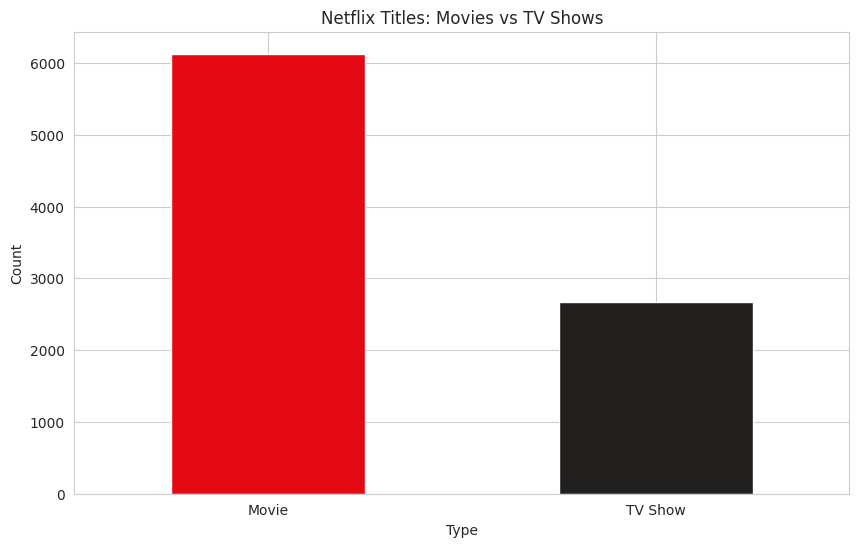

In [12]:
plt.figure()
type_counts.plot(kind="bar", color=["#E50914", "#221f1f"])
plt.title("Netflix Titles: Movies vs TV Shows")
plt.xlabel("Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


### Chart 2 — Bar chart: Top 10 countries by number of titles

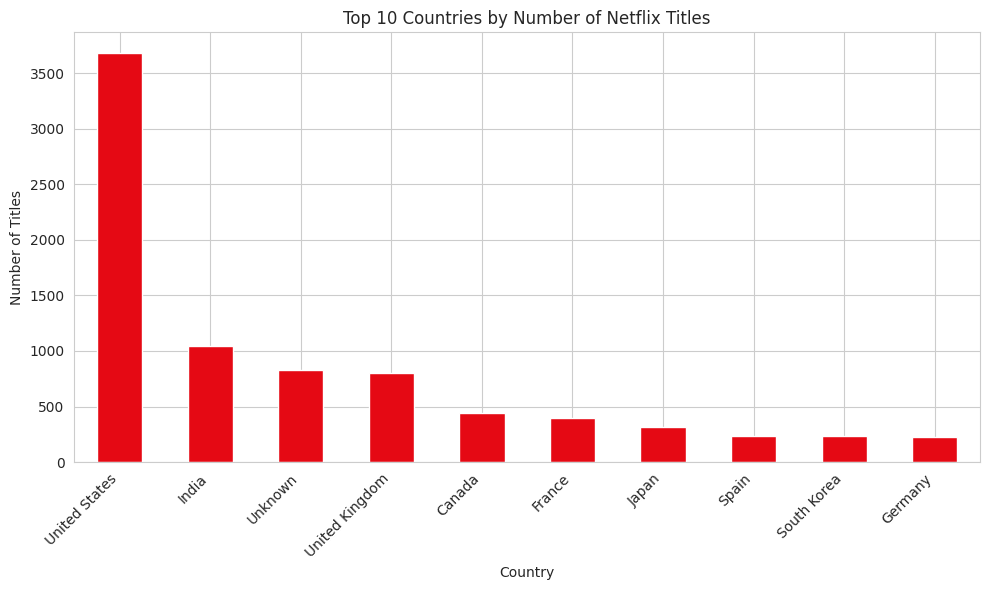

In [13]:
plt.figure()
top_countries.plot(kind="bar", color="#E50914")
plt.title("Top 10 Countries by Number of Netflix Titles")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Chart 3 — Line chart: Titles added per year

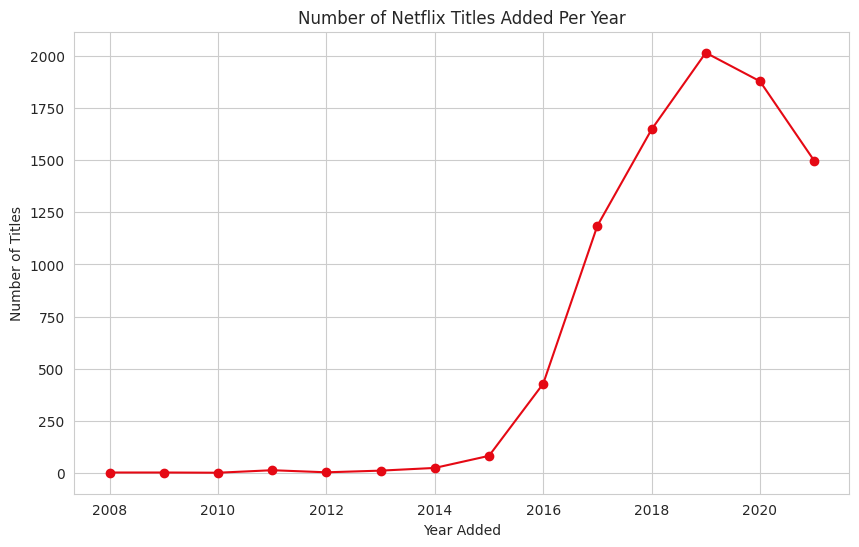

In [14]:
plt.figure()
titles_per_year.plot(kind="line", marker="o", color="#E50914")
plt.title("Number of Netflix Titles Added Per Year")
plt.xlabel("Year Added")
plt.ylabel("Number of Titles")
plt.show()


### Chart 4 — Histogram: Distribution of movie durations (minutes)

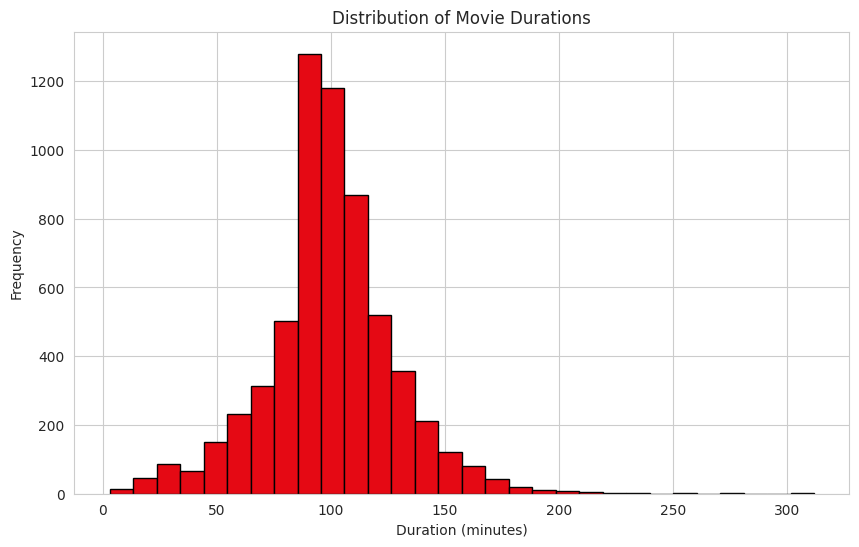

In [15]:
plt.figure()
movie_durations = df_clean[df_clean["type"] == "Movie"]["duration_num"].dropna()
plt.hist(movie_durations, bins=30, color="#E50914", edgecolor="black")
plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Frequency")
plt.show()


### Chart 5 — Pie chart: Top 5 content ratings share

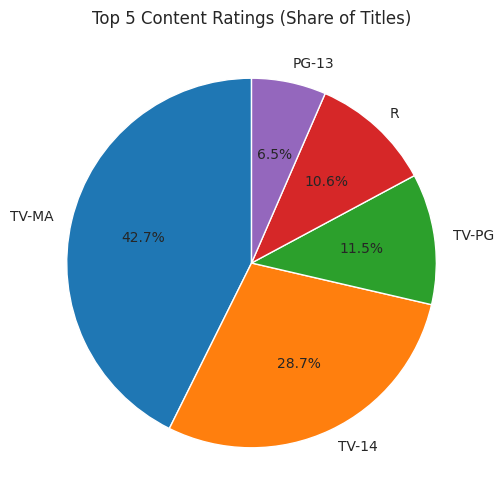

In [16]:
plt.figure()
rating_summary.head(5).plot(
    kind="pie", autopct="%1.1f%%", startangle=90
)
plt.title("Top 5 Content Ratings (Share of Titles)")
plt.ylabel("")
plt.show()


### Chart 6 — Scatter plot: Release year vs. duration (movies)

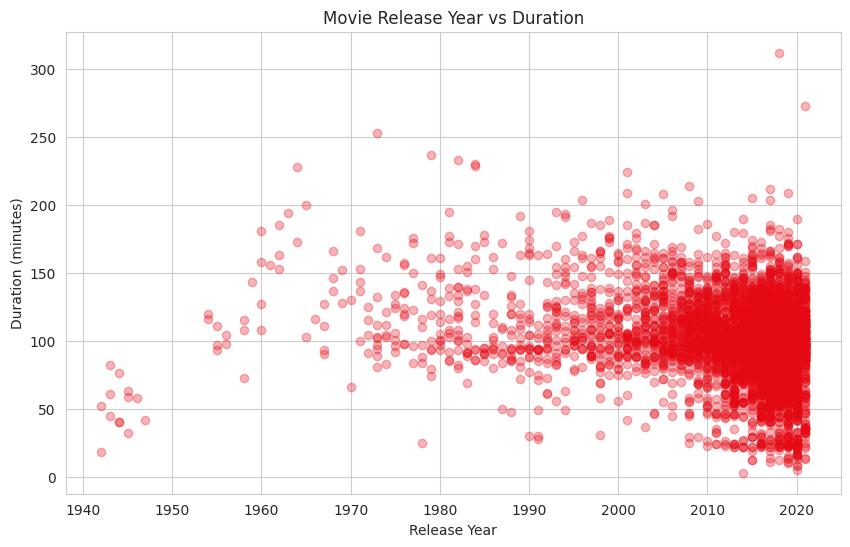

In [17]:
plt.figure()
movies_df = df_clean[df_clean["type"] == "Movie"]
plt.scatter(movies_df["release_year"], movies_df["duration_num"], alpha=0.3, color="#E50914")
plt.title("Movie Release Year vs Duration")
plt.xlabel("Release Year")
plt.ylabel("Duration (minutes)")
plt.show()


### Chart 7 (bonus) — Heatmap: Titles by year_added vs type

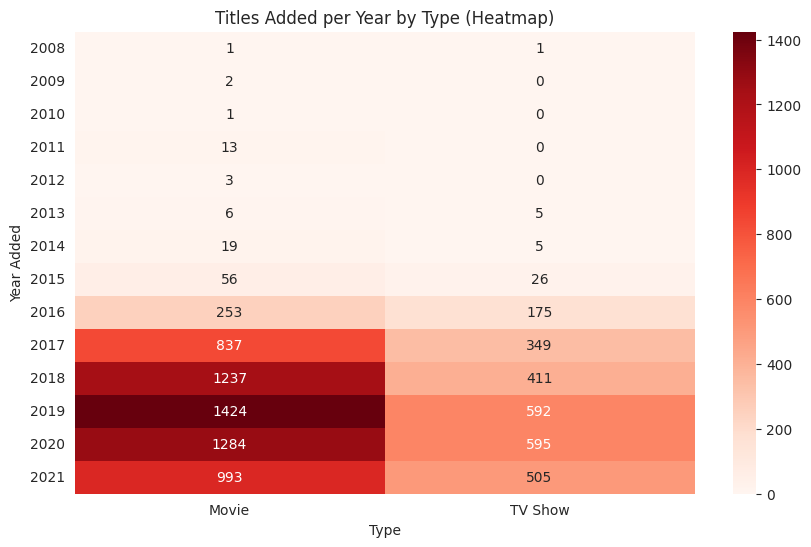

In [18]:
pivot = df_clean.pivot_table(index="year_added", columns="type", values="title", aggfunc="count").fillna(0)
plt.figure()
sns.heatmap(pivot, cmap="Reds", annot=True, fmt=".0f")
plt.title("Titles Added per Year by Type (Heatmap)")
plt.xlabel("Type")
plt.ylabel("Year Added")
plt.show()
